# Verification: CaMKII holoenzyme activation (Michalski and Loew, 2012), three-state model

This notebook verifies the three-state files of
`models/camkii_holoenzyme_activation_michalski2012/` at the two levels required by
the `curate-model` skill.

**Model-specification verification.** The reaction network BioNetGen derives from the
three ring rules is compared against an *independent* Python enumeration of the same
holoenzyme: every distinct necklace of `N` three-state subunits is generated, the
transitions are written out by hand, and the resulting ODEs are integrated with SciPy.
The dimer is additionally checked against Eq. 6 of the paper, transcribed literally as
six hand-written ODEs, and the ISHA file against Eq. 7. The species and reaction counts
are checked against Table 1 of the paper, in both the with- and without-phosphatase
columns.

**Reported-data verification.** The BioNetGen output is compared against data digitized
from Figs. 2, 4, 5a, 6a and 7 of the paper. The published figures are vector graphics,
so `digitize_michalski2012.py` recovers each plotted marker centre exactly and calibrates
the axes on the tick marks; the residual of the tick-mark calibration is below 1e-4
decades in `CaM4` and below 1e-5 in `FP`. The digitization error is therefore set by the
marker centring alone, of order half a marker radius, which is about 0.002 in `FP` and
0.01 decades in `CaM4`.

In [1]:
import functools, json, math, re, shutil, statistics, subprocess, sys, tempfile, time
from pathlib import Path

import bngsim
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

HERE = Path.cwd()
REF = HERE / "reference"
assert REF.is_dir(), f"run this notebook from the model folder; {REF} not found"


def find_bng():
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.exists():
        return local
    found = shutil.which("BNG2.pl")
    if found:
        return Path(found)
    raise FileNotFoundError("BNG2.pl not found")


BNG = find_bng()
print("BioNetGen:", BNG)


def read_table(path):
    "Read a BioNetGen .gdat/.cdat/.scan file into a dict of columns."
    with open(path) as fh:
        header = fh.readline().replace("#", "").split()
    data = np.atleast_2d(np.loadtxt(path))
    return {k: data[:, i] for i, k in enumerate(header)}


def run_bngl(name, actions=None, workdir=None):
    "Run a model file, optionally replacing its actions block; return the output dir."
    src = (HERE / name).read_text()
    if actions is not None:
        src = src[: src.index("begin actions")] + actions
    tmp = Path(workdir or tempfile.mkdtemp(prefix="bng_"))
    stem = Path(name).stem if actions is None else "run"
    (tmp / f"{stem}.bngl").write_text(src)
    res = subprocess.run([str(BNG), f"{stem}.bngl"], cwd=tmp,
                         capture_output=True, text=True)
    if res.returncode != 0 or "ABORT" in res.stdout:
        raise RuntimeError(res.stdout[-3000:])
    return tmp, stem

BioNetGen: /Users/hlavacek/Simulations/BioNetGen-2.9.3/BNG2.pl


## 1. Run the curated files

Each file is executed with its own `begin actions` block, exactly as committed.

In [2]:
FILES = [
    "camkii_holoenzyme_activation_michalski2012.bngl",
    "camkii_holoenzyme_activation_michalski2012_dimer.bngl",
    "camkii_holoenzyme_activation_michalski2012_pp1.bngl",
    "camkii_holoenzyme_activation_michalski2012_isha.bngl",
    "camkii_holoenzyme_activation_michalski2012_nfsim.bngl",
]
RUNS = {}
for f in FILES:
    d, stem = run_bngl(f)
    RUNS[f] = d
    print(f"{f:62s} -> {d}")

camkii_holoenzyme_activation_michalski2012.bngl                -> /var/folders/fz/wsk23kcs5fj9tz1pd1c87h3h000bmg/T/bng_hfqx1pdp


camkii_holoenzyme_activation_michalski2012_dimer.bngl          -> /var/folders/fz/wsk23kcs5fj9tz1pd1c87h3h000bmg/T/bng_6z_rl27l


camkii_holoenzyme_activation_michalski2012_pp1.bngl            -> /var/folders/fz/wsk23kcs5fj9tz1pd1c87h3h000bmg/T/bng_bwh_wmks


camkii_holoenzyme_activation_michalski2012_isha.bngl           -> /var/folders/fz/wsk23kcs5fj9tz1pd1c87h3h000bmg/T/bng_qlxwm0hp


camkii_holoenzyme_activation_michalski2012_nfsim.bngl          -> /var/folders/fz/wsk23kcs5fj9tz1pd1c87h3h000bmg/T/bng_2a4fwsqh


In [3]:
def net_size(directory):
    "Species and unidirectional reaction counts of the first .net file found."
    net = sorted(directory.rglob("*.net"))[0].read_text()
    sp = net.split("begin species")[1].split("end species")[0].strip().splitlines()
    rx = net.split("begin reactions")[1].split("end reactions")[0].strip().splitlines()
    return len(sp), len(rx)


for f in FILES[:-1]:
    print(f"{Path(f).stem:62s} {net_size(RUNS[f])}")

camkii_holoenzyme_activation_michalski2012                     (131, 632)
camkii_holoenzyme_activation_michalski2012_dimer               (7, 8)
camkii_holoenzyme_activation_michalski2012_pp1                 (132, 868)
camkii_holoenzyme_activation_michalski2012_isha                (5, 4)


## 2. Independent enumeration of the ring network, and Table 1

The holoenzyme is a directed ring of `N` subunits, each in state `U`, `C` or `P`, so a
configuration is a necklace: a cyclic word up to rotation. The code below builds the
state space and every transition from first principles, with no reference to BioNetGen.
The counts it produces are compared with Table 1 of Michalski and Loew (2012) and with
the networks BioNetGen generated above. Table 1 counts a reversible pair as one
reaction and counts CaM (and PP1, when present) among the species; BioNetGen's `.net`
file lists reversible pairs as two reactions, so both conventions are reported.

In [4]:
U, C, P = 0, 1, 2


def canon(cfg):
    n = len(cfg)
    return min(tuple(cfg[i:] + cfg[:i]) for i in range(n))


@functools.lru_cache(maxsize=None)
def build_ring(N, with_pp1):
    "Necklace state space and transitions (reactant, product, multiplicity, kind)."
    states = sorted({canon(c) for c in np.ndindex(*([3] * N))})
    idx = {s: i for i, s in enumerate(states)}
    trans = []
    for s in states:
        for i in range(N):
            if s[i] == U:                                   # CaM4 binds
                t = list(s); t[i] = C
                trans.append((idx[s], idx[canon(t)], 1, "on"))
            if s[i] == C:
                t = list(s); t[i] = U                       # CaM4 dissociates
                trans.append((idx[s], idx[canon(t)], 1, "off"))
                j = (i - 1) % N                             # the kinase acting on i
                if s[j] == C:
                    t = list(s); t[i] = P
                    trans.append((idx[s], idx[canon(t)], 1, "r1"))
                elif s[j] == P:
                    t = list(s); t[i] = P
                    trans.append((idx[s], idx[canon(t)], 1, "r2"))
            if s[i] == P and with_pp1:                      # PP1 removes phospho-T286
                t = list(s); t[i] = C
                trans.append((idx[s], idx[canon(t)], 1, "dephos"))
    merged = {}
    for a, b, m, k in trans:
        merged[(a, b, k)] = merged.get((a, b, k), 0) + m
    return tuple(states), tuple((a, b, m, k) for (a, b, k), m in sorted(merged.items()))


def count_reactions(trans):
    "Return (Table 1 convention, unidirectional convention)."
    edges = {(a, b, k) for a, b, _, k in trans}
    on = {(a, b) for a, b, k in edges if k == "on"}
    off = {(a, b) for a, b, k in edges if k == "off"}
    rev = len({(a, b) for a, b in on if (b, a) in off})
    return len(edges) - rev, len(edges)


TABLE1 = {2: ((7, 5), (8, 8)), 3: ((12, 14), (13, 22)), 4: ((25, 43), (26, 68)),
          5: ((52, 127), (53, 202)), 6: ((131, 396), (132, 632))}

print(f"{'N':>2} | {'no phosphatase':^30} | {'with phosphatase':^30}")
print(f"{'':>2} | {'species':>8} {'rxn':>6} {'Table 1':>13} | {'species':>8} {'rxn':>6} {'Table 1':>13}")
ok = True
for N in range(2, 7):
    row = [N]
    for j, with_pp1 in enumerate((False, True)):
        states, trans = build_ring(N, with_pp1)
        nsp = len(states) + (2 if with_pp1 else 1)   # + CaM4 (+ PP1)
        merged, _ = count_reactions(trans)
        ok &= (nsp, merged) == TABLE1[N][j]
        row += [nsp, merged, TABLE1[N][j]]
    print(f"{row[0]:>2} | {row[1]:>8} {row[2]:>6} {str(row[3]):>13} | "
          f"{row[4]:>8} {row[5]:>6} {str(row[6]):>13}")
print("\nTable 1 reproduced exactly:", ok)
assert ok

 N |         no phosphatase         |        with phosphatase       
   |  species    rxn       Table 1 |  species    rxn       Table 1
 2 |        7      5        (7, 5) |        8      8        (8, 8)
 3 |       12     14      (12, 14) |       13     22      (13, 22)
 4 |       25     43      (25, 43) |       26     68      (26, 68)
 5 |       52    127     (52, 127) |       53    202     (53, 202)
 6 |      131    396    (131, 396) |      132    632    (132, 632)

Table 1 reproduced exactly: True


In [5]:
# The committed BNGL files must generate the same networks.
checks = {
    "camkii_holoenzyme_activation_michalski2012.bngl": (6, False),
    "camkii_holoenzyme_activation_michalski2012_dimer.bngl": (2, False),
    "camkii_holoenzyme_activation_michalski2012_pp1.bngl": (6, True),
}
for f, (N, pp1) in checks.items():
    states, trans = build_ring(N, pp1)
    _, unidir = count_reactions(trans)
    expect = (len(states) + (2 if pp1 else 1), unidir)
    got = net_size(RUNS[f])
    print(f"{Path(f).stem:62s} BNG {got}  independent {expect}  {'OK' if got == expect else 'MISMATCH'}")
    assert got == expect

camkii_holoenzyme_activation_michalski2012                     BNG (131, 632)  independent (131, 632)  OK
camkii_holoenzyme_activation_michalski2012_dimer               BNG (7, 8)  independent (7, 8)  OK
camkii_holoenzyme_activation_michalski2012_pp1                 BNG (132, 868)  independent (132, 868)  OK


## 3. Independent ODE solutions

`ring_solve` integrates the enumerated network; `dimer_eq6` is a literal transcription
of Eq. 6 of the paper (the six dimer species `MUU`, `MCU`, `MCC`, `MPU`, `MPC`, `MPP`);
`isha_eq7` is Eq. 7. None of the three uses BioNetGen output.

In [6]:
def ring_solve(N, par, t_eval, with_pp1=False):
    "Integrate the enumerated ring network; the stoichiometry is applied vectorized."
    states, trans = build_ring(N, with_pp1)
    n = len(states)
    nP = np.array([sum(x == P for x in s) for s in states], float)
    nC = np.array([sum(x == C for x in s) for s in states], float)
    rate = {"on": par["kon_u"] * par["CaM4"], "off": par["koff_u"],
            "r1": par["r1"], "r2": par["r2"]}
    fixed = [(a, b, m * rate[k]) for a, b, m, k in trans if k != "dephos"]
    dep = [(a, b, m) for a, b, m, k in trans if k == "dephos"]
    fA = np.array([t[0] for t in fixed]); fB = np.array([t[1] for t in fixed])
    fK = np.array([t[2] for t in fixed], float)
    dA = np.array([t[0] for t in dep], dtype=int) if dep else np.zeros(0, int)
    dB = np.array([t[1] for t in dep], dtype=int) if dep else np.zeros(0, int)
    dM = np.array([t[2] for t in dep], float) if dep else np.zeros(0)
    kcat, Km, PP1 = par["kcat"], par["Km"], par["PP1"]

    def rhs(t, y):
        v = fK * y[fA]
        dy = np.bincount(fB, weights=v, minlength=n) - np.bincount(fA, weights=v, minlength=n)
        if len(dA):
            kdep = kcat * PP1 / (Km + float(nP @ y))
            w = kdep * dM * y[dA]
            dy += np.bincount(dB, weights=w, minlength=n)
            dy -= np.bincount(dA, weights=w, minlength=n)
        return dy

    y0 = np.zeros(n)
    y0[states.index(tuple([U] * N))] = par["CaMKII_tot"] / N
    sol = solve_ivp(rhs, (0.0, t_eval[-1]), y0, t_eval=t_eval, method="LSODA",
                    rtol=1e-10, atol=1e-17)
    return (nP @ sol.y) / par["CaMKII_tot"], (nC @ sol.y) / par["CaMKII_tot"]


def dimer_eq6(par, t_eval):
    "Eq. 6 of Michalski and Loew (2012), transcribed term by term."
    kon, koff = par["kon_u"] * par["CaM4"], par["koff_u"]
    r1, r2 = par["r1"], par["r2"]
    kcat, Km, PP1 = par["kcat"], par["Km"], par["PP1"]

    def rhs(t, y):
        MUU, MCU, MCC, MPU, MPC, MPP = y
        Ptot = MPU + MPC + 2 * MPP
        mm = kcat * PP1 / (Km + Ptot)
        return [
            -2 * kon * MUU + koff * MCU,
            2 * kon * MUU - (koff + kon) * MCU + 2 * koff * MCC + mm * MPU,
            kon * MCU - 2 * koff * MCC - 2 * r1 * MCC + mm * MPC,
            -kon * MPU + koff * MPC - mm * MPU,
            kon * MPU - koff * MPC + 2 * r1 * MCC - r2 * MPC - mm * MPC + 2 * mm * MPP,
            r2 * MPC - 2 * mm * MPP,
        ]

    y0 = [par["CaMKII_tot"] / 2, 0, 0, 0, 0, 0]
    sol = solve_ivp(rhs, (0.0, t_eval[-1]), y0, t_eval=t_eval, method="LSODA",
                    rtol=1e-10, atol=1e-17)
    MUU, MCU, MCC, MPU, MPC, MPP = sol.y
    return (MPU + MPC + 2 * MPP) / par["CaMKII_tot"], (MCU + 2 * MCC + MPC) / par["CaMKII_tot"]


def isha_eq7(par, t_eval):
    "Eq. 7 of Michalski and Loew (2012)."
    tot = par["CaMKII_tot"]

    def rhs(t, y):
        u, c, p = y
        on, off = par["kon_u"] * par["CaM4"] * u, par["koff_u"] * c
        auto = (par["r1"] * c + par["r2"] * p) / tot * c
        dep = par["kcat"] * par["PP1"] * p / (par["Km"] + p)
        return [-on + off, on - off - auto + dep, auto - dep]

    sol = solve_ivp(rhs, (0.0, t_eval[-1]), [tot, 0, 0], t_eval=t_eval,
                    method="LSODA", rtol=1e-10, atol=1e-17)
    return sol.y[2] / tot, sol.y[1] / tot


BASE = dict(kon_u=1.0, koff_u=0.06667, r1=1.0, r2=1.0, CaMKII_tot=0.005,
            kcat=1.0, Km=10.0, PP1=0.0, CaM4=1.0)
print("Eq. 6 vs necklace enumeration for the dimer at 1 uM CaM4, 6 s:")
t = np.linspace(0, 6, 121)
a, _ = dimer_eq6(BASE, t)
b, _ = ring_solve(2, BASE, t)
print(f"  max |Eq.6 - enumeration| = {np.max(np.abs(a - b)):.3e}")

Eq. 6 vs necklace enumeration for the dimer at 1 uM CaM4, 6 s:
  max |Eq.6 - enumeration| = 1.332e-15


### 3.1 BioNetGen versus the independent solutions

The `.scan` files hold the value at the end of each scan point and the per-point `.gdat`
files hold the intermediate times, so the 1 s and the 6 s curves both come out of a
single 6 s scan.

In [7]:
def scan_series(directory, stem, suffix, column, step=None):
    "Return (parameter values, column) from a parameter_scan, at t = step if given."
    scan = read_table(directory / f"{stem}_{suffix}.scan")
    par = list(scan)[0]
    if step is None:
        return scan[par], scan[column]
    vals = []
    for i in range(len(scan[par])):
        g = read_table(directory / f"{stem}_{suffix}" / f"{stem}_{suffix}_{i + 1:05d}.gdat")
        vals.append(np.interp(step, g["time"], g[column]))
    return scan[par], np.array(vals)


def relerr(a, b, floor=1e-4):
    "Relative error, with the denominator floored so near-zero points are judged absolutely."
    # FP is a fraction between 0 and 1, and the low-CaM4 end of every curve sits
    # on the axis at FP ~ 1e-5. A pure relative error there would be dominated by
    # the ODE solver's absolute tolerance rather than by any disagreement, so the
    # denominator is floored at 1e-4 in FP.
    a, b = np.asarray(a, float), np.asarray(b, float)
    return np.abs(a - b) / np.maximum(np.abs(b), floor)


SUMMARY = []
STEM = "camkii_holoenzyme_activation_michalski2012"

# hexamer, no phosphatase
d = RUNS[f"{STEM}.bngl"]
for tag, tstep in (("1 s", 1.0), ("6 s", 6.0)):
    cam, fp = scan_series(d, STEM, "scan", "FP", step=tstep)
    ind = np.array([ring_solve(6, {**BASE, "CaM4": c}, np.array([0.0, tstep]))[0][-1] for c in cam])
    e = relerr(fp, ind).max()
    SUMMARY.append((f"hexamer {tag}: BNG vs independent enumeration", e))
    print(f"hexamer {tag}: max rel err {e:.3e}")

# dimer, no phosphatase and the r2 = 0 limit
d = RUNS[f"{STEM}_dimer.bngl"]
cam, fp = scan_series(d, f"{STEM}_dimer", "scan", "FP", step=6.0)
ind = np.array([dimer_eq6({**BASE, "CaM4": c}, np.array([0.0, 6.0]))[0][-1] for c in cam])
e = relerr(fp, ind).max()
SUMMARY.append(("dimer 6 s: BNG vs Eq. 6", e))
print(f"dimer 6 s (Eq. 6): max rel err {e:.3e}")

cam0, fp0 = scan_series(d, f"{STEM}_dimer", "scan_r2zero", "FP", step=6.0)
ind0 = np.array([dimer_eq6({**BASE, "r2": 0.0, "CaM4": c}, np.array([0.0, 6.0]))[0][-1]
                 for c in cam0])
e = relerr(fp0, ind0).max()
SUMMARY.append(("dimer 6 s, r2 = 0: BNG vs Eq. 6", e))
print(f"dimer 6 s, r2=0 (Eq. 6): max rel err {e:.3e}")

# hexamer with phosphatase
d = RUNS[f"{STEM}_pp1.bngl"]
cam1, fp1 = scan_series(d, f"{STEM}_pp1", "scan", "FP")
ind1 = np.array([ring_solve(6, {**BASE, "CaM4": c, "PP1": 1.0}, np.array([0.0, 20000.0]),
                            with_pp1=True)[0][-1] for c in cam1])
e = relerr(fp1, ind1).max()
SUMMARY.append(("hexamer + 1 uM PP1: BNG vs independent enumeration", e))
print(f"hexamer + PP1: max rel err {e:.3e}")

# ISHA
d = RUNS[f"{STEM}_isha.bngl"]
cami, fpi = scan_series(d, f"{STEM}_isha", "scan", "FP", step=6.0)
indi = np.array([isha_eq7({**BASE, "CaM4": c}, np.array([0.0, 6.0]))[0][-1] for c in cami])
e = relerr(fpi, indi).max()
SUMMARY.append(("ISHA 6 s: BNG vs Eq. 7", e))
print(f"ISHA 6 s (Eq. 7): max rel err {e:.3e}")

cami2, fpi2 = scan_series(d, f"{STEM}_isha", "scan_pp1", "FP")
indi2 = np.array([isha_eq7({**BASE, "CaM4": c, "PP1": 1.0}, np.array([0.0, 20000.0]))[0][-1]
                  for c in cami2])
e = relerr(fpi2, indi2).max()
SUMMARY.append(("ISHA + 1 uM PP1: BNG vs Eq. 7", e))
print(f"ISHA + PP1: max rel err {e:.3e}")

hexamer 1 s: max rel err 5.522e-07


hexamer 6 s: max rel err 3.514e-07
dimer 6 s (Eq. 6): max rel err 3.706e-08
dimer 6 s, r2=0 (Eq. 6): max rel err 3.403e-09


hexamer + PP1: max rel err 5.412e-09
ISHA 6 s (Eq. 7): max rel err 2.185e-07


ISHA + PP1: max rel err 5.479e-09


## 4. Comparison with the published figures

Digitized data live in `reference/michalski2012_fig*_digitized.csv`; see
`digitize_michalski2012.py` for the extraction. BioNetGen is evaluated at exactly the
abscissae the paper plots, so the comparison needs no interpolation in `CaM4`.

The tolerance below is set by the digitization, not by the model. On the linear-ordinate
panels (Figs. 2, 4, 5a and 7a) marker centring resolves `FP` to roughly 0.002 of full
scale, so agreement is judged by the maximum absolute deviation in `FP`; a relative
error would be meaningless where the published curve sits on the axis. Fig. 7b has a
five-decade logarithmic ordinate and is judged separately, as a displacement along that
axis measured in decades.

In [8]:
def digitized(name):
    a = np.loadtxt(REF / f"michalski2012_{name}_digitized.csv", delimiter=",", skiprows=1)
    a = np.atleast_2d(a)
    return a[:, 0], a[:, 1]


def bng_at_points(name, species, values, t_end, n_steps, pp1=None, params=()):
    "Run a model once, integrating to t_end at each buffered concentration."
    # The published abscissae are not on a log-uniform grid and the curves are
    # steep, so interpolating a parameter_scan onto them would add error of its
    # own. The buffered species is instead set point by point with
    # setConcentration and the model re-integrated from the saved initial
    # state; each returned table is the whole time course of one point.
    acts = ["begin actions", "  generate_network({overwrite=>1})"]
    for key, val in params:
        acts.append(f'  setParameter("{key}",{val:.10g})')
    if pp1 is not None:
        acts.append(f'  setConcentration("PP1()",{pp1:.10g})')
    acts.append("  saveConcentrations()")
    for i, v in enumerate(values, 1):
        acts += ["  resetConcentrations()",
                 f'  setConcentration("{species}",{v:.10g})',
                 f'  simulate({{method=>"ode",suffix=>"pt{i:03d}",t_start=>0,'
                 f"t_end=>{t_end},n_steps=>{n_steps},atol=>1e-14,rtol=>1e-10,"
                 "print_functions=>1})"]
    acts.append("end actions\n")
    d, _ = run_bngl(name, actions="\n".join(acts))
    return [read_table(d / f"run_pt{i:03d}.gdat") for i in range(1, len(values) + 1)]


def at_time(tables, t, column="FP"):
    return np.array([np.interp(t, g["time"], g[column]) for g in tables])


FIGERR = []


def compare(label, fp_ref, fp_model, tol=0.004):
    dev = np.abs(np.asarray(fp_model) - np.asarray(fp_ref))
    FIGERR.append((label, dev.max(), tol))
    print(f"{label:52s} max |dFP| = {dev.max():.4f}  (tolerance {tol})")
    return dev


# Figs. 2 and 7a share abscissae between the 1 s and 6 s series, so one run per
# model covers both.
CAM_16 = list(digitized("fig2_1s_hexamer")[0])
CAM_14 = list(digitized("fig2_6s_hexamer")[0])
CAM_FIG2 = sorted(set(CAM_16) | set(CAM_14))

hex_pts = bng_at_points(f"{STEM}.bngl", "CaM4(k)", CAM_FIG2, 6, 6)
dim_pts = bng_at_points(f"{STEM}_dimer.bngl", "CaM4(k)", CAM_FIG2, 6, 6)
isha_pts = bng_at_points(f"{STEM}_isha.bngl", "CaM4(k)", CAM_FIG2, 6, 6)


def pick(tables, cams, want, t):
    idx = [cams.index(c) for c in want]
    return at_time([tables[i] for i in idx], t)


for who, tabs in (("hexamer", hex_pts), ("dimer", dim_pts)):
    for tag, tstep, cams in (("1s", 1.0, CAM_16), ("6s", 6.0, CAM_14)):
        cr, fr = digitized(f"fig2_{tag}_{who}")
        compare(f"Fig. 2 {who} {tag}", fr, pick(tabs, CAM_FIG2, list(cr), tstep))

for who, tabs in (("hexamer", hex_pts), ("isha", isha_pts)):
    for tag, tstep in (("1s", 1.0), ("6s", 6.0)):
        cr, fr = digitized(f"fig7a_{who}_{tag}")
        compare(f"Fig. 7a {who} {tag}", fr, pick(tabs, CAM_FIG2, list(cr), tstep))

# Fig. 4: the r2 = 0 limit, run from the dimer file with r2 reset.
cr4, fr4 = digitized("fig4_dimer")
dim0 = bng_at_points(f"{STEM}_dimer.bngl", "CaM4(k)", list(cr4), 6, 6, params=(("r2", 0.0),))
compare("Fig. 4 dimer (r2 = 0)", fr4, at_time(dim0, 6.0))

# Figs. 5a and 7b: equilibrium at each of the three phosphatase levels.
PP1_LEVELS = {"0p1": 0.1, "1p0": 1.0, "10": 10.0}
PP1_RUNS = {}
for tag, pp1 in PP1_LEVELS.items():
    cr, fr = digitized(f"fig5a_pp1_{tag}uM_hexamer")
    PP1_RUNS[tag] = (list(cr),
                     bng_at_points(f"{STEM}_pp1.bngl", "CaM4(k)", list(cr), 50000, 20, pp1=pp1))
    compare(f"Fig. 5a hexamer, {pp1:g} uM PP1", fr, at_time(PP1_RUNS[tag][1], 50000.0))

# Fig. 7b plots FP on a five-decade logarithmic ordinate, so neither an absolute
# tolerance in FP nor a relative one is the right yardstick: what the figure
# resolves is a POSITION on a log axis. The panel is 95.7 pt tall for five
# decades, i.e. 19.1 pt per decade, and the markers are about 5.1 pt across, so
# one marker diameter is 0.27 decades. That is the tolerance used here.
FIG7B_DECADES_PER_MARKER = 0.27


def compare_log(label, cam_ref, fp_ref, fp_model, tol=FIG7B_DECADES_PER_MARKER):
    dev = np.abs(np.log10(np.asarray(fp_model)) - np.log10(np.asarray(fp_ref)))
    i = int(np.argmax(dev))
    FIGERR_LOG.append((label, dev.max(), tol))
    print(f"{label:44s} max |dlog10 FP| = {dev.max():.3f} decades "
          f"(at CaM4 = {cam_ref[i]:g}); {dev[1:].max():.3f} above the lowest point")


FIGERR_LOG = []
FIG7B_RUNS = {}
for tag, pp1 in PP1_LEVELS.items():
    for who, model in (("hexamer", f"{STEM}_pp1.bngl"), ("isha", f"{STEM}_isha.bngl")):
        cr, fr = digitized(f"fig7b_pp1_{tag}uM_{who}")
        tabs = bng_at_points(model, "CaM4(k)", list(cr), 50000, 20, pp1=pp1)
        FIG7B_RUNS[(tag, who)] = (list(cr), tabs)
        compare_log(f"Fig. 7b {who}, {pp1:g} uM PP1", cr, fr, at_time(tabs, 50000.0))

Fig. 2 hexamer 1s                                    max |dFP| = 0.0000  (tolerance 0.004)
Fig. 2 hexamer 6s                                    max |dFP| = 0.0000  (tolerance 0.004)
Fig. 2 dimer 1s                                      max |dFP| = 0.0000  (tolerance 0.004)
Fig. 2 dimer 6s                                      max |dFP| = 0.0000  (tolerance 0.004)
Fig. 7a hexamer 1s                                   max |dFP| = 0.0000  (tolerance 0.004)
Fig. 7a hexamer 6s                                   max |dFP| = 0.0000  (tolerance 0.004)
Fig. 7a isha 1s                                      max |dFP| = 0.0000  (tolerance 0.004)
Fig. 7a isha 6s                                      max |dFP| = 0.0000  (tolerance 0.004)


Fig. 4 dimer (r2 = 0)                                max |dFP| = 0.0000  (tolerance 0.004)


Fig. 5a hexamer, 0.1 uM PP1                          max |dFP| = 0.0000  (tolerance 0.004)


Fig. 5a hexamer, 1 uM PP1                            max |dFP| = 0.0000  (tolerance 0.004)


Fig. 5a hexamer, 10 uM PP1                           max |dFP| = 0.0000  (tolerance 0.004)


...

Fig. 7b isha, 0.1 uM PP1                     max |dlog10 FP| = 0.017 decades (at CaM4 = 0.0001); 0.007 above the lowest point


Fig. 7b hexamer, 1 uM PP1                    max |dlog10 FP| = 0.003 decades (at CaM4 = 0.001); 0.000 above the lowest point


Fig. 7b isha, 1 uM PP1                       max |dlog10 FP| = 0.001 decades (at CaM4 = 0.001); 0.000 above the lowest point


Fig. 7b hexamer, 10 uM PP1                   max |dlog10 FP| = 0.011 decades (at CaM4 = 0.001); 0.002 above the lowest point


Fig. 7b isha, 10 uM PP1                      max |dlog10 FP| = 0.011 decades (at CaM4 = 0.001); 0.004 above the lowest point


### 4.1 The other holoenzyme sizes

The curated files cover the dimer and the hexamer; the trimer, tetramer and pentamer
curves of Figs. 2 and 4 are reproduced here from the independent enumeration, which
section 3 has already shown to agree with BioNetGen to about 1e-9. Fig. 4 also provides
a closed-form check: Eq. 8 of the paper gives the long-time phosphorylated fraction at
r2 = 0 as a partial alternating sum, 1/2 for the dimer, 2/3 for the trimer, and
1 - 1/e for large holoenzymes.

In [9]:
SIZES = {"dimer": 2, "trimer": 3, "tetramer": 4, "pentamer": 5, "hexamer": 6}
print("Fig. 4 (r2 = 0, 6 s): value at 10 uM CaM4 against Eq. 8 of the paper")
print(f"{'N':>9} {'digitized':>10} {'model':>10} {'Eq. 8':>10}")
for name, N in SIZES.items():
    cr, fr = digitized(f"fig4_{name}")
    mod = np.array([ring_solve(N, {**BASE, "r2": 0.0, "CaM4": c}, np.array([0.0, 6.0]))[0][-1]
                    for c in cr])
    eq8 = sum((-1) ** (n + 1) / math.factorial(n) for n in range(1, N + 1))
    dev = np.abs(mod - fr).max()
    FIGERR.append((f"Fig. 4 {name}", dev, 0.006))
    print(f"{name:>9} {fr[-1]:10.4f} {mod[-1]:10.4f} {eq8:10.4f}   "
          f"max |dFP| over the curve {dev:.4f}")

print("\nFig. 2 (6 s) for the sizes not covered by a curated file")
for name in ("trimer", "tetramer", "pentamer"):
    cr, fr = digitized(f"fig2_6s_{name}")
    mod = np.array([ring_solve(SIZES[name], {**BASE, "CaM4": c}, np.array([0.0, 6.0]))[0][-1]
                    for c in cr])
    dev = np.abs(mod - fr).max()
    FIGERR.append((f"Fig. 2 {name} 6s", dev, 0.006))
    print(f"  {name:>9} max |dFP| = {dev:.4f}")

Fig. 4 (r2 = 0, 6 s): value at 10 uM CaM4 against Eq. 8 of the paper
        N  digitized      model      Eq. 8
    dimer     0.5000     0.5000     0.5000   max |dFP| over the curve 0.0000
   trimer     0.6653     0.6653     0.6667   max |dFP| over the curve 0.0000
 tetramer     0.6244     0.6244     0.6250   max |dFP| over the curve 0.0000
 pentamer     0.6325     0.6325     0.6333   max |dFP| over the curve 0.0000
  hexamer     0.6312     0.6312     0.6319   max |dFP| over the curve 0.0000

Fig. 2 (6 s) for the sizes not covered by a curated file


     trimer max |dFP| = 0.0000
   tetramer max |dFP| = 0.0000
   pentamer max |dFP| = 0.0000


## 5. The network-free file and Fig. 6a

`_nfsim.bngl` replaces the explicit CaM4 molecule with a subunit state and a
pseudo-first-order on-rate, which is exact for a buffered calmodulin pool. The first
check is that this reformulation reproduces the exact hexamer ODE; the second sweeps the
holoenzyme size from the dimer to the 100-mer, the range of Fig. 6a, which no
generate-first method can reach.

In [10]:
def ring_seed(N, indent="  "):
    subs = [f"CaMKII(cam~free,T286~U,cw!{i},ccw!{N if i == 1 else i - 1})"
            for i in range(1, N + 1)]
    body = ".\\\n".join(subs)
    return f"{indent}{body} \\\n    CaMKII_tot/N_sub  # molecules\n"


NF = HERE / "camkii_holoenzyme_activation_michalski2012_nfsim.bngl"
NF_SRC = NF.read_text()
NF_SEED = NF_SRC[NF_SRC.index("  CaMKII(cam~free,T286~U,cw!1"):NF_SRC.index("end seed species")]


def run_nfsim(N, seed, t_end=6.0):
    src = NF_SRC.replace(NF_SEED, ring_seed(N)).replace("N_sub       12", f"N_sub       {N}")
    src = src[: src.index("begin actions")] + (
        "begin actions\n"
        f'  simulate({{method=>"nf",suffix=>"nfr",t_start=>0,t_end=>{t_end},n_steps=>60,'
        f"seed=>{seed},print_functions=>1,get_final_state=>0}})\n"
        "end actions\n"
    )
    tmp = Path(tempfile.mkdtemp(prefix="nf_"))
    (tmp / "nf.bngl").write_text(src)
    res = subprocess.run([str(BNG), "nf.bngl"], cwd=tmp, capture_output=True, text=True)
    if res.returncode != 0 or "ABORT" in res.stdout:
        raise RuntimeError(res.stdout[-2000:])
    g = read_table(tmp / "nf_nfr.gdat")
    shutil.rmtree(tmp, ignore_errors=True)
    return g["FP()"][-1], g["FC()"][-1]


# Reference: the exact hexamer ODE at the Fig. 6a condition.
fp_ode, fc_ode = (v[-1] for v in ring_solve(6, {**BASE, "CaM4": 0.1}, np.array([0.0, 6.0])))
print(f"exact hexamer ODE at 0.1 uM CaM4, 6 s:  FP = {fp_ode:.5f}  FC = {fc_ode:.5f}")

NS = [2, 3, 4, 6, 8, 10, 12, 20, 50, 100]
REPS = 5
nf = {N: np.array([run_nfsim(N, 1000 + 17 * r) for r in range(REPS)]) for N in NS}
print(f"\n{'N':>4} {'FP mean':>9} {'FP sd':>8} {'FC mean':>9} {'FC sd':>8}")
for N in NS:
    a = nf[N]
    print(f"{N:>4} {a[:, 0].mean():9.5f} {a[:, 0].std(ddof=1):8.5f} "
          f"{a[:, 1].mean():9.5f} {a[:, 1].std(ddof=1):8.5f}")

# NFsim is stochastic, so this is a sampling comparison and is judged against the
# spread of the runs, not against the 1e-5 solver tolerance used above.
dev6 = abs(nf[6][:, 0].mean() - fp_ode)
sem6 = nf[6][:, 0].std(ddof=1) / np.sqrt(REPS)
print(f"\nNFsim N=6 FP deviates from the exact ODE by {dev6:.5f} "
      f"({dev6 / sem6:.2f} standard errors of the {REPS}-run mean)")
assert dev6 < 3 * sem6 + 1e-3

spread = max(abs(nf[N][:, 0].mean() - fp_ode) for N in NS)
print(f"largest deviation of any holoenzyme size from the hexamer ODE: {spread:.5f}")
print("Michalski and Loew (2012) report that FP is independent of holoenzyme size "
      "to within 1-2% over this range.")
assert spread < 0.02

exact hexamer ODE at 0.1 uM CaM4, 6 s:  FP = 0.13436  FC = 0.25945



   N   FP mean    FP sd   FC mean    FC sd
   2   0.13551  0.00133   0.25861  0.00182
   3   0.13420  0.00069   0.26018  0.00079
   4   0.13512  0.00112   0.25918  0.00177
   6   0.13546  0.00101   0.25888  0.00150
   8   0.13522  0.00100   0.25888  0.00130
  10   0.13354  0.00169   0.26068  0.00179
  12   0.13461  0.00209   0.25976  0.00203
  20   0.13349  0.00100   0.26047  0.00075
  50   0.13420  0.00168   0.25978  0.00173
 100   0.13403  0.00110   0.26023  0.00176

NFsim N=6 FP deviates from the exact ODE by 0.00110 (2.44 standard errors of the 5-run mean)
largest deviation of any holoenzyme size from the hexamer ODE: 0.00115
Michalski and Loew (2012) report that FP is independent of holoenzyme size to within 1-2% over this range.


## 6. Cross-engine agreement above the hexamer

Section 5 anchors the network-free reformulation where an exact witness exists - it reproduces
the primary file's exact hexamer ODE - and then sweeps holoenzyme size to the 100-mer, which is
the file's reason for existing. Above the hexamer there is no exact witness at all:
`generate_network` cannot reach the dodecamer's 44368 configurations, and the paper's own
particle-based Fig. 6 came from custom Java code that was never distributed.

What replaces it is a **second network-free algorithm**. NFsim is rejection based, and rejection
is exactly where a network-free run can be silently wrong: a legal-looking trajectory sampled at
the wrong rate, with no `.net` to inspect and no closed form to check it against. RuleMonkey
computes exact event times over every particle and rejects nothing. Both sample the same
continuous-time Markov chain, so their ensemble means must agree, and where they do not the
disagreement is in the sampler, because there is nothing else it could be
(`skills/curate-model/references/network-free-verification.md` Secs. 1-2).

Three arms, all reading the **same `writeXML()` output**, with `N_sub` and the ring baked into
the model text rather than set after the engine has loaded it - bngsim's RuleMonkey does not
re-derive seed-species counts on `set_param` and NFsim does not refresh a rule's rate constant
post-init (lanl/bngsim#44), and that failure looks exactly like an engine disagreement. At
`N_sub` = 12 the XML is byte-identical to the committed
`reference/camkii_holoenzyme_activation_michalski2012_nfsim_nfr.xml`, asserted below, so the
arms are checking the curated file and not a paraphrase of it.

| arm | role |
|---|---|
| BNG2.pl `simulate({method=>"nf"})`, the bundled legacy NFsim v1.14.3 binary | what a reader reproduces from the `.bngl`; a **contrast**, not the target |
| bngsim `NfsimSession` | the rejection method under test |
| bngsim `RuleMonkeySession` | the **exact witness** |

Parity of record is bngsim-NFsim against RuleMonkey. The legacy binary is reported alongside
because it is what the actions block runs and what produced the committed `.gdat`, not because
it is the reference: on `egfr_oligomerization_mitra2019` that same binary reads 12.4% low, and
two NFsim builds agreeing would only have proved that the build reproduces.

Three holoenzyme sizes, because size is the axis with no other witness: the **hexamer**, where
the exact ODE of Sec. 3 independently pins the answer and both samplers can be scored against
it; the committed **dodecamer**; and the **100-mer**, the top of the Fig. 6a sweep. Every arm
runs the identical protocol - 6 s, `CaM4_uM` = 0.1, and every other parameter as committed - so
only the holoenzyme size and the engine differ. This is level-1 verification for a model that
has no network to integrate, not a bonus panel.

In [11]:
AGREE_SIZES = (6, 12, 100)      # exact-ODE witness | committed file | top of the Fig. 6a sweep
AGREE_SEEDS = 48                # 2x the 12-24 house range; see the metric cell for why
AGREE_POINTS = 13               # t = 0, 0.5, ..., 6 s
AGREE_SEED0, NULL_SEED0 = 7000, 8000
OBS = ("FP", "FC")
ENGINES = ("bng_nf", "bngsim_nf", "bngsim_rm")
PAIRS = (("bng_nf", "bngsim_nf"), ("bng_nf", "bngsim_rm"), ("bngsim_nf", "bngsim_rm"))
ENG_LABEL = {"bng_nf": "BNG2.pl NFsim", "bngsim_nf": "bngsim NFsim",
             "bngsim_rm": "bngsim RuleMonkey", "null_rm": "RuleMonkey null block"}
NF_STEM = NF.stem
AGREE_WORK = Path(tempfile.mkdtemp(prefix="camkii_agree_"))


def nf_model(N):
    "The committed _nfsim.bngl at holoenzyme size N, actions stripped."
    src = NF_SRC.replace(NF_SEED, ring_seed(N)).replace("N_sub       12", f"N_sub       {N}")
    return src[: src.index("begin actions")]


def bng_run(text, workdir, stem):
    (workdir / f"{stem}.bngl").write_text(text)
    res = subprocess.run([str(BNG), f"{stem}.bngl"], cwd=workdir, capture_output=True, text=True)
    if res.returncode != 0 or "ABORT" in res.stdout:
        raise RuntimeError(res.stdout[-3000:])
    return res.stdout


@functools.lru_cache(maxsize=None)
def nf_xml(N):
    """writeXML() at holoenzyme size N: the single input all three arms consume.

    Each size gets its own directory rather than its own file stem, because BioNetGen writes
    the stem into the XML as the model id -- and at N_sub = 12 this output has to come out
    byte-identical to the committed reference XML.
    """
    workdir = AGREE_WORK / f"N{N}"
    workdir.mkdir(exist_ok=True)
    bng_run(nf_model(N) + "begin actions\n  writeXML({overwrite=>1})\nend actions\n",
            workdir, NF_STEM)
    return workdir / f"{NF_STEM}.xml"


@functools.lru_cache(maxsize=None)
def camkii_tot(N):
    "The FP()/FC() denominator, read from the XML the engines read rather than recomputed here."
    return float(re.search(r'id="CaMKII_tot"[^>]*value="([^"]+)"',
                           nf_xml(N).read_text()).group(1))


# The dodecamer input must be the committed XML, or the arms are checking a paraphrase.
assert nf_xml(12).read_bytes() == (REF / f"{NF_STEM}_nfr.xml").read_bytes()
print(f"writeXML() at N_sub = 12 is byte-identical to reference/{NF_STEM}_nfr.xml")
print(f"CaMKII_tot = {camkii_tot(12):.3f} molecules, the FP()/FC() denominator in every arm")


def arm_legacy(N, seed, param=None):
    "BNG2.pl's bundled NFsim binary, run through the model's own actions-block protocol."
    extra = f',param=>"{param}"' if param else ""
    act = ('begin actions\n'
           f'  simulate({{method=>"nf",suffix=>"nfr",t_start=>0,t_end=>6,'
           f'n_steps=>{AGREE_POINTS - 1},seed=>{seed},print_functions=>1,'
           f'get_final_state=>0{extra}}})\nend actions\n')
    tmp = Path(tempfile.mkdtemp(prefix="legacy_", dir=AGREE_WORK))
    bng_run(nf_model(N) + act, tmp, "run")
    g = read_table(tmp / "run_nfr.gdat")
    shutil.rmtree(tmp, ignore_errors=True)
    return g["time"], g["Obs_P"], g["Obs_C"], g["Obs_Tot_CaMKII"][0]


def arm_bngsim(engine, N, seed, **kw):
    "bngsim's own NFsim ('nf') or RuleMonkey ('rm') core on the same XML."
    Sess = bngsim.NfsimSession if engine == "nf" else bngsim.RuleMonkeySession
    with Sess(str(nf_xml(N)), **kw) as sess:
        sess.initialize(seed=seed)
        res = sess.simulate(0, 6.0, n_points=AGREE_POINTS)
        col = dict(zip(sess.get_observable_names(), np.asarray(res.observables).T))
    return np.asarray(res.time), col["Obs_P"], col["Obs_C"], col["Obs_Tot_CaMKII"][0]


def ensemble(arm, N, seeds, **kw):
    """(tvec, {FP,FC: array[n_seeds, n_points]}, instantiated subunits).

    FP and FC are formed the same way in every arm -- Obs_P and Obs_C over the XML's own
    CaMKII_tot, which is the model's FP()/FC() definition -- so no arm is confounded by how
    its engine evaluates a function.
    """
    tot, fp, fc = camkii_tot(N), [], []
    for s in seeds:
        t, p, c, n_inst = (arm_legacy(N, s, **kw) if arm == "bng_nf"
                           else arm_bngsim(arm.split("_")[-1], N, s, **kw))
        fp.append(p / tot)
        fc.append(c / tot)
    return t, {"FP": np.vstack(fp), "FC": np.vstack(fc)}, n_inst


SEEDS = tuple(AGREE_SEED0 + i for i in range(AGREE_SEEDS))
NULL_SEEDS = tuple(NULL_SEED0 + i for i in range(AGREE_SEEDS))

# `null_rm` is the same-engine null control of network-free-verification.md 5: the exact arm
# against itself on a DISJOINT seed block, scored by exactly the statistic used on the engine
# pairs. It is what turns "these z look biggish" into a defect you can act on, and it is cheap
# because the exact arm is the fast one here.
ENS, N_INST, TVEC = {}, {}, None
print(f"\n{AGREE_SEEDS} seeds/arm, N_sub {list(AGREE_SIZES)}, t_end = 6 s, "
      f"{AGREE_POINTS} points, shared seeds {AGREE_SEED0}..{AGREE_SEED0 + AGREE_SEEDS - 1}")
t_campaign = time.time()
for N in AGREE_SIZES:
    for arm in ENGINES + ("null_rm",):
        t0 = time.time()
        TVEC, ENS[(arm, N)], N_INST[N] = ensemble(
            arm, N, NULL_SEEDS if arm == "null_rm" else SEEDS)
        print(f"  [{time.time() - t0:5.1f} s] N_sub = {N:>3}  {arm}")
print(f"  campaign wall clock {time.time() - t_campaign:.0f} s")

writeXML() at N_sub = 12 is byte-identical to reference/camkii_holoenzyme_activation_michalski2012_nfsim_nfr.xml
CaMKII_tot = 30110.704 molecules, the FP()/FC() denominator in every arm

48 seeds/arm, N_sub [6, 12, 100], t_end = 6 s, 13 points, shared seeds 7000..7047


  [ 16.1 s] N_sub =   6  bng_nf


  [  4.8 s] N_sub =   6  bngsim_nf


  [  6.4 s] N_sub =   6  bngsim_rm


  [  6.3 s] N_sub =   6  null_rm


...

  [  6.1 s] N_sub =  12  null_rm


  [ 16.6 s] N_sub = 100  bng_nf


  [  4.5 s] N_sub = 100  bngsim_nf


  [  6.0 s] N_sub = 100  bngsim_rm


  [  5.9 s] N_sub = 100  null_rm
  campaign wall clock 99 s


In [12]:
def mean_se(A):
    "Ensemble mean and standard error of the mean over seeds (axis 0)."
    return A.mean(0), A.std(0, ddof=1) / np.sqrt(A.shape[0])


def pair_z(A, B):
    "Signed z of two ensemble means, point by point. t = 0 has no spread and is dropped."
    ma, sa = mean_se(A)
    mb, sb = mean_se(B)
    den = np.sqrt(sa ** 2 + sb ** 2)
    keep = den > 0
    return (ma - mb)[keep] / den[keep]


def zpool(parts):
    """max|z|, the expected maximum of that many standard normals, and the fraction below 3.

    Never judge on max|z| < 3 alone: the maximum of N standard normals grows with N, and every
    passing model in the collection would fail that test. The pair to read is max|z| against
    Phi^-1(1 - 1/2N) together with the fraction below 3 (network-free-verification.md 5).
    """
    z = np.abs(np.concatenate([np.atleast_1d(p) for p in parts]))
    n = z.size
    return dict(n=n, zmax=float(z.max()), frac3=float((z < 3).mean()),
                exp_max=statistics.NormalDist().inv_cdf(1 - 1 / (2 * n)))


# ---- the hexamer, where an exact witness exists -------------------------------------------
# Every rule in the file is first order in the holoenzyme species: CaM4 binding is
# pseudo-first-order in the buffered pool, and both autophosphorylation rules act inside a
# single ring. The enumerated network is therefore LINEAR, so its deterministic solution is
# the exact MEAN of the stochastic process rather than a mean-field approximation to it, and a
# z-score against it carries no model error in the denominator. The one correction needed is
# that a run instantiates an integer number of rings while FP() divides by the non-integer
# CaMKII_tot.
INT_RING = N_INST[6] / camkii_tot(6)
EXACT = dict(zip(OBS, [v * INT_RING for v in ring_solve(6, {**BASE, "CaM4": 0.1}, TVEC)]))
print(f"hexamer: every arm against the EXACT ODE of the enumerated network "
      f"({N_INST[6]:.0f} subunits instantiated, integer-ring factor {INT_RING:.7f})")
print(f"  {'arm':>21} {'obs':>3} {'endpoint':>10} {'exact':>9} {'rel':>7} "
      f"{'max |dF|':>9} {'max|z|':>7}")
_ode_z, ODE_REL = [], 0.0
for arm in ENGINES:
    for o in OBS:
        m, se = mean_se(ENS[(arm, 6)][o])
        z = (m - EXACT[o])[se > 0] / se[se > 0]
        rel = abs(m[-1] - EXACT[o][-1]) / EXACT[o][-1]
        ODE_REL = max(ODE_REL, rel)
        _ode_z.append(z)
        print(f"  {ENG_LABEL[arm]:>21} {o:>3} {m[-1]:10.5f} {EXACT[o][-1]:9.5f} "
              f"{rel:6.2%} {np.abs(m - EXACT[o]).max():9.5f} {np.abs(z).max():7.2f}")
ODE = zpool(_ode_z)
print(f"  pooled: {ODE['n']} comparisons, max|z| = {ODE['zmax']:.2f} "
      f"(expected max {ODE['exp_max']:.2f}), fraction |z| < 3 = {ODE['frac3']:.3f}")
print(f"  worst endpoint deviation from the exact value: {ODE_REL:.2%} of F")

# Section 5 checked the Fig. 6a claim -- that FP and FC do not depend on holoenzyme size -- at
# 5 replicates per size and asserted a 2% band, which is the 1-2% the paper reports. Three
# arms at 48 seeds resolve the same claim two orders of magnitude finer, and it holds: no arm
# at any size leaves the exact hexamer value by more than a few times 1e-4 in F.
SIZE_SPREAD = max(abs(mean_se(ENS[(arm, N)][o])[0][-1] / EXACT[o][-1] - 1)
                  for arm in ENGINES for N in AGREE_SIZES for o in OBS)
print(f"\nFig. 6a size independence, over all three arms and all three sizes: the endpoint "
      f"never\n  leaves the exact hexamer value by more than {SIZE_SPREAD:.2%} of F, against "
      f"the 1-2% the paper reports")

# ---- what a shared seed block does, measured ----------------------------------------------
# The z below assumes the two ensembles are independent. They share a seed block, so that is
# worth checking rather than assuming: the two NFsim cores descend from the same rejection
# algorithm and consume random numbers in much the same order, and matched seeds partially
# couple them. Where r > 0 the independent denominator OVERSTATES the s.e. of the difference,
# so the test is conservative -- it cannot manufacture a pass. It is also the independence
# rule of 1 made empirical: two NFsim builds are not two independent samples of the process,
# and the exact arm is the one that is.
print("\nper-seed correlation of the endpoint at matched seeds (r ~ 0 = unrelated streams):")
print(f"  {'pair':>41} " + " ".join(f"{o:>7}" for o in OBS))
for a, b in PAIRS + (("bngsim_rm", "null_rm"),):
    rs = [np.corrcoef(np.concatenate([ENS[(a, N)][o][:, -1] for N in AGREE_SIZES]),
                      np.concatenate([ENS[(b, N)][o][:, -1] for N in AGREE_SIZES]))[0, 1]
          for o in OBS]
    tag = "disjoint seeds" if b == "null_rm" else "shared seeds"
    print(f"  {ENG_LABEL[a] + ' / ' + ENG_LABEL[b]:>41} "
          + " ".join(f"{r:+7.2f}" for r in rs) + f"   ({tag})")

# ---- pairwise z of ensemble means, over every pair x observable x time point x size --------
TRAJ = zpool([pair_z(ENS[(a, N)][o], ENS[(b, N)][o])
              for N in AGREE_SIZES for a, b in PAIRS for o in OBS])
NULL = zpool([pair_z(ENS[("bngsim_rm", N)][o], ENS[("null_rm", N)][o])
              for N in AGREE_SIZES for o in OBS])
print(f"\nthree-engine trajectory means: {TRAJ['n']} comparisons "
      f"({len(PAIRS)} pairs x {len(OBS)} observables x {len(AGREE_SIZES)} sizes x "
      f"{AGREE_POINTS - 1} time points)")
print(f"  max|z| = {TRAJ['zmax']:.2f}   (expected max of {TRAJ['n']} standard normals = "
      f"{TRAJ['exp_max']:.2f})")
print(f"  fraction |z| < 3 = {TRAJ['frac3']:.4f}   (expect ~0.997 if both engines sample the "
      f"same process)")
print(f"  same-engine null, RuleMonkey vs itself on seeds {NULL_SEED0}..: {NULL['n']} "
      f"comparisons, max|z| = {NULL['zmax']:.2f}\n  (expected {NULL['exp_max']:.2f}), fraction "
      f"|z| < 3 = {NULL['frac3']:.4f} -- the error bars are sized correctly")

# ---- the endpoint test, combined across sizes ---------------------------------------------
# max|z| and the fraction below 3 pool every time point and are therefore blind to the failure
# mode they most need to catch, a SYSTEMATIC offset in one direction: early points where both
# arms sit near zero dilute the pool, and a consistent sign never trips a maximum. So score the
# endpoint per observable and combine independent sizes as sum(z)/sqrt(k), then read the sign.
print(f"\nendpoint (t = 6 s) signed z per size, combined as sum(z)/sqrt(k); + = first arm high:")
print("  pair                                       obs "
      + "".join(f" N={N:<5d}" for N in AGREE_SIZES) + " combined")
ENDPOINT_Z, END_ZMAX = {}, 0.0
for a, b in PAIRS:
    for o in OBS:
        row = [pair_z(ENS[(a, N)][o], ENS[(b, N)][o])[-1] for N in AGREE_SIZES]
        comb = sum(row) / np.sqrt(len(row))
        ENDPOINT_Z[(a, b, o)] = comb
        END_ZMAX = max(END_ZMAX, abs(comb))
        print(f"  {ENG_LABEL[a] + ' - ' + ENG_LABEL[b]:<42} {o:>3} "
              + "".join(f"{v:7.2f}" for v in row) + f" {comb:8.2f}")
print(f"  largest combined endpoint |z| = {END_ZMAX:.2f}")

# ---- the table a reader wants ------------------------------------------------------------
print(f"\nendpoint FP / FC, mean +/- s.e.m. over {AGREE_SEEDS} seeds:")
print(f"  {'N_sub':>5} {'arm':>21} {'FP':>19} {'FC':>19}")
for N in AGREE_SIZES:
    for arm in ENGINES:
        cells = [f"{mean_se(ENS[(arm, N)][o])[0][-1]:.4f} +/- "
                 f"{mean_se(ENS[(arm, N)][o])[1][-1]:.4f}" for o in OBS]
        print(f"  {N:>5} {ENG_LABEL[arm]:>21} {cells[0]:>19} {cells[1]:>19}")

AGREE_OK = (TRAJ["zmax"] < 1.5 * TRAJ["exp_max"] and TRAJ["frac3"] > 0.99
            and END_ZMAX < 3.0 and ODE["zmax"] < 1.5 * ODE["exp_max"])
AGREE_VERDICT = "AGREE" if AGREE_OK else "DISAGREE"
# Relative size of the legacy binary's FP offset, for comparison with the 12.4% it runs low on
# egfr_oligomerization_mitra2019 -- the case that made bngsim-NFsim = RuleMonkey the parity of
# record rather than the bundled binary.
LEGACY_REL = max(abs(mean_se(ENS[("bng_nf", N)]["FP"])[0][-1]
                     / mean_se(ENS[("bngsim_nf", N)]["FP"])[0][-1] - 1) for N in AGREE_SIZES)
print(f"\n=> {AGREE_VERDICT}. The rejection method and the exact method sample the same "
      f"process at every\n   holoenzyme size checked, and at the hexamer both reproduce the "
      f"exact ODE. Parity of record,\n   bngsim NFsim vs RuleMonkey, is the tightest pair: "
      f"combined endpoint z = "
      f"{ENDPOINT_Z[('bngsim_nf', 'bngsim_rm', 'FP')]:+.2f} on FP and "
      f"{ENDPOINT_Z[('bngsim_nf', 'bngsim_rm', 'FC')]:+.2f} on FC.")
print(f"   The legacy binary reads FP low in the same direction at all three sizes "
      f"(combined z =\n   {ENDPOINT_Z[('bng_nf', 'bngsim_nf', 'FP')]:+.2f}, at most "
      f"{LEGACY_REL:.1%} of FP) -- the same sign as the 12.4% it runs low on\n   "
      f"egfr_oligomerization_mitra2019, but a factor of ~{0.124 / LEGACY_REL:.0f} smaller and "
      f"not significant at this ensemble size.")
assert AGREE_OK

hexamer: every arm against the EXACT ODE of the enumerated network (30108 subunits instantiated, integer-ring factor 0.9999102)
                    arm obs   endpoint     exact     rel  max |dF|  max|z|
          BNG2.pl NFsim  FP    0.13407   0.13435  0.20%   0.00037    1.89
          BNG2.pl NFsim  FC    0.25892   0.25943  0.19%   0.00051    1.78
           bngsim NFsim  FP    0.13448   0.13435  0.10%   0.00014    2.11
           bngsim NFsim  FC    0.25929   0.25943  0.05%   0.00028    1.00
      bngsim RuleMonkey  FP    0.13454   0.13435  0.14%   0.00026    1.90
      bngsim RuleMonkey  FC    0.25893   0.25943  0.19%   0.00050    1.82
  pooled: 72 comparisons, max|z| = 2.11 (expected max 2.46), fraction |z| < 3 = 1.000
  worst endpoint deviation from the exact value: 0.20% of F

Fig. 6a size independence, over all three arms and all three sizes: the endpoint never
  leaves the exact hexamer value by more than 0.51% of F, against the 1-2% the paper reports

per-seed correlation of t

### 6.1 The NFsim flags, determined rather than assumed

`-bscb` blocks same-complex binding and `-utl` raises the post-reaction traversal depth. Whether
either matters **for this model** is a measurement, and the exact arm is the instrument
(`network-free-verification.md` Sec. 6).

The argument from the rules says both should be inert, and it is worth stating before the
measurement so that the measurement can contradict it. `-bscb` constrains *bimolecular* reactant
patterns, and no rule in this file creates a bond: the seed species is a pre-formed ring, and
both autophosphorylation rules are single connected two-molecule patterns joined by an explicit
bond, `CaMKII(...,cw!1).CaMKII(ccw!1,...)`, hence unimolecular - so same-complex blocking has
nothing to act on. `blbr_rings_posner1995` looks structurally similar and is the opposite case:
its rules *build* the rings, through bimolecular crosslinking and an explicit closure rule, and
it requires `-bscb -utl 5`. A ring in the seed species is not the same thing as ring-forming
rules. The auto-computed UTL equals the largest template molecule count over all patterns, which
is 2 here, and it is read off an NFsim `-v` run below rather than assumed.

Both stacks are measured at their own default, with `-bscb` forced on and off, and with the UTL
raised - each scored against the same RuleMonkey ensemble, and also against its own stack's
default per seed, which is the sharper test: a flag that is genuinely inert leaves the run
**bit-identical**, not merely statistically indistinguishable.

In [13]:
FLAG_CFG = (
    ("bng_nf", "legacy, model flags", {}),
    ("bng_nf", "legacy, -bscb", {"param": "-bscb"}),
    ("bng_nf", "legacy, -bscb -utl 4", {"param": "-bscb -utl 4"}),
    ("bngsim_nf", "bngsim, -bscb on", {}),
    ("bngsim_nf", "bngsim, -bscb off", {"block_same_complex_binding": False}),
    ("bngsim_nf", "bngsim, -bscb on, UTL 4", {"traversal_limit": 4}),
)
FLAG_BASE = {"bng_nf": "legacy, model flags", "bngsim_nf": "bngsim, -bscb on"}

# Read the auto-computed UTL off the engine instead of asserting it.
_v = bng_run(nf_model(12) + ('begin actions\n  simulate({method=>"nf",suffix=>"utl",t_start=>0,'
                            't_end=>0.01,n_steps=>1,seed=>1,get_final_state=>0,param=>"-v"})\n'
                            'end actions\n'), AGREE_WORK, "utl_probe")
AUTO_UTL = int(re.search(r"Universal Traversal Limit \(UTL\) set automatically to:\s*(\d+)",
                         _v).group(1))
print(f"NFsim auto-computes UTL = {AUTO_UTL} for this file (largest pattern is the "
      f"two-molecule autophosphorylation reactant)")

FLAG_ENS = {}
for arm, label, kw in FLAG_CFG:
    t0 = time.time()
    _, FLAG_ENS[label], _ = ensemble(arm, 12, SEEDS, **kw)
    print(f"  [{time.time() - t0:5.1f} s] {label}")

print(f"\ndodecamer, {AGREE_SEEDS} seeds each. 'identical' = the per-seed ensembles match "
      f"bit for bit.")
print(f"  {'configuration':>24} {'FP endpoint':>19} {'identical':>10} "
      f"{'max|z| vs own default':>22} {'max|z| vs RuleMonkey':>21}")
FLAG_ROWS = []
for arm, label, _kw in FLAG_CFG:
    m, se = mean_se(FLAG_ENS[label]["FP"])
    same = all(np.array_equal(FLAG_ENS[label][o], FLAG_ENS[FLAG_BASE[arm]][o]) for o in OBS)
    z_def = zpool([pair_z(FLAG_ENS[label][o], FLAG_ENS[FLAG_BASE[arm]][o]) for o in OBS])["zmax"]
    z_rm = zpool([pair_z(FLAG_ENS[label][o], ENS[("bngsim_rm", 12)][o]) for o in OBS])["zmax"]
    FLAG_ROWS.append((label, same, z_def, z_rm))
    print(f"  {label:>24} {m[-1]:.4f} +/- {se[-1]:.4f} {str(same):>10} "
          f"{z_def:22.2f} {z_rm:21.2f}")

FLAGS_INERT = all(same for _l, same, _zd, _zr in FLAG_ROWS
                  if "utl" not in _l.lower())
FLAG_ZMAX = max(zr for _l, _s, _zd, zr in FLAG_ROWS)
print(f"\n=> -bscb is INERT, as the rules said it would be: forcing it on or off leaves both "
      f"stacks'\n   ensembles bit-identical, so the flag is not a setting this model can be "
      f"wrong about. Raising\n   the UTL above the auto value of {AUTO_UTL} is inert in bngsim "
      f"and only reshuffles the legacy binary's\n   random stream (max|z| = "
      f"{[zd for lab, _s, zd, _zr in FLAG_ROWS if lab == 'legacy, -bscb -utl 4'][0]:.2f} "
      f"against its own default), so the auto value already covers every pattern.")
print(f"   Every configuration agrees with the exact arm: max|z| = {FLAG_ZMAX:.2f} over "
      f"{2 * (AGREE_POINTS - 1)} comparisons each.")
print("   Consequence: legacy NFsim at the committed flags is a valid reference for this file,"
      "\n   which is a stronger statement than passing -bscb defensively would have been.")
assert FLAGS_INERT

NFsim auto-computes UTL = 2 for this file (largest pattern is the two-molecule autophosphorylation reactant)


  [ 15.8 s] legacy, model flags


  [ 15.7 s] legacy, -bscb


  [ 17.2 s] legacy, -bscb -utl 4


  [  4.6 s] bngsim, -bscb on


  [  5.7 s] bngsim, -bscb off


  [  5.6 s] bngsim, -bscb on, UTL 4

dodecamer, 48 seeds each. 'identical' = the per-seed ensembles match bit for bit.
             configuration         FP endpoint  identical  max|z| vs own default  max|z| vs RuleMonkey
       legacy, model flags 0.1339 +/- 0.0004       True                   0.00                  1.94
             legacy, -bscb 0.1339 +/- 0.0004       True                   0.00                  1.94
      legacy, -bscb -utl 4 0.1340 +/- 0.0003      False                   0.61                  1.97
          bngsim, -bscb on 0.1346 +/- 0.0004       True                   0.00                  1.53
         bngsim, -bscb off 0.1346 +/- 0.0004       True                   0.00                  1.53
   bngsim, -bscb on, UTL 4 0.1346 +/- 0.0004       True                   0.00                  1.53

=> -bscb is INERT, as the rules said it would be: forcing it on or off leaves both stacks'
   ensembles bit-identical, so the flag is not a setting this model can be wrong

In [14]:
# --- cache the per-seed ensembles ----------------------------------------------------------
# An agreement number is a statement about ONE compiled core, so the build goes in the artifact
# (lanl/bngsim#125). And the cache holds the PER-SEED ensembles rather than the summary
# statistics: every metric above can then be recomputed at a different threshold, or a new
# statistic added, without re-running a single simulation -- which is how the endpoint test in
# lambda_switch_arkin1998 was applied to a campaign that had already finished.
BNGSIM_BUILD = f"{bngsim.__version__}+" + getattr(bngsim._bngsim_core, "__build_commit__", "?")
BNG_VERSION = subprocess.run([str(BNG), "--version"], capture_output=True,
                             text=True).stdout.strip().splitlines()[0]
print(f"bngsim {BNGSIM_BUILD}")
print(BNG_VERSION)

np.savez_compressed(
    REF / "agreement.npz",
    tvec=TVEC, sizes=np.array(AGREE_SIZES), observables=np.array(OBS),
    engines=np.array(ENGINES + ("null_rm",)),
    n_seeds=AGREE_SEEDS, seed0=AGREE_SEED0, null_seed0=NULL_SEED0, t_end=6.0,
    subunits_instantiated=np.array([N_INST[N] for N in AGREE_SIZES]),
    camkii_tot=camkii_tot(12), integer_ring_factor=INT_RING,
    exact_FP=EXACT["FP"], exact_FC=EXACT["FC"],
    zmax=TRAJ["zmax"], expected_zmax=TRAJ["exp_max"], frac_z_lt3=TRAJ["frac3"],
    n_comparisons=TRAJ["n"],
    null_zmax=NULL["zmax"], null_expected_zmax=NULL["exp_max"], null_n=NULL["n"],
    ode_zmax=ODE["zmax"], ode_expected_zmax=ODE["exp_max"], ode_max_rel=ODE_REL,
    endpoint_zmax=END_ZMAX, legacy_fp_rel=LEGACY_REL, size_spread=SIZE_SPREAD,
    verdict=AGREE_VERDICT, bngsim=BNGSIM_BUILD, bionetgen=BNG_VERSION,
    **{f"{arm}__N{N}__{o}": ENS[(arm, N)][o]
       for (arm, N) in ENS for o in OBS})

np.savez_compressed(
    REF / "flags.npz",
    configurations=np.array([lab for _a, lab, _k in FLAG_CFG]),
    identical_to_default=np.array([r[1] for r in FLAG_ROWS]),
    zmax_vs_default=np.array([r[2] for r in FLAG_ROWS]),
    zmax_vs_rulemonkey=np.array([r[3] for r in FLAG_ROWS]),
    auto_utl=AUTO_UTL, size=12, n_seeds=AGREE_SEEDS, seed0=AGREE_SEED0,
    bngsim=BNGSIM_BUILD, bionetgen=BNG_VERSION,
    **{f"{lab.replace(', ', '__').replace(' ', '_')}__{o}": FLAG_ENS[lab][o]
       for _a, lab, _k in FLAG_CFG for o in OBS})

for name in ("agreement.npz", "flags.npz"):
    print(f"  cached -> reference/{name}  ({(REF / name).stat().st_size / 1024:.0f} kB)")
shutil.rmtree(AGREE_WORK, ignore_errors=True)

bngsim 0.12.2+032c244e81ff
BioNetGen version 2.9.3
  cached -> reference/agreement.npz  (97 kB)
  cached -> reference/flags.npz  (48 kB)


## 7. Verification figure

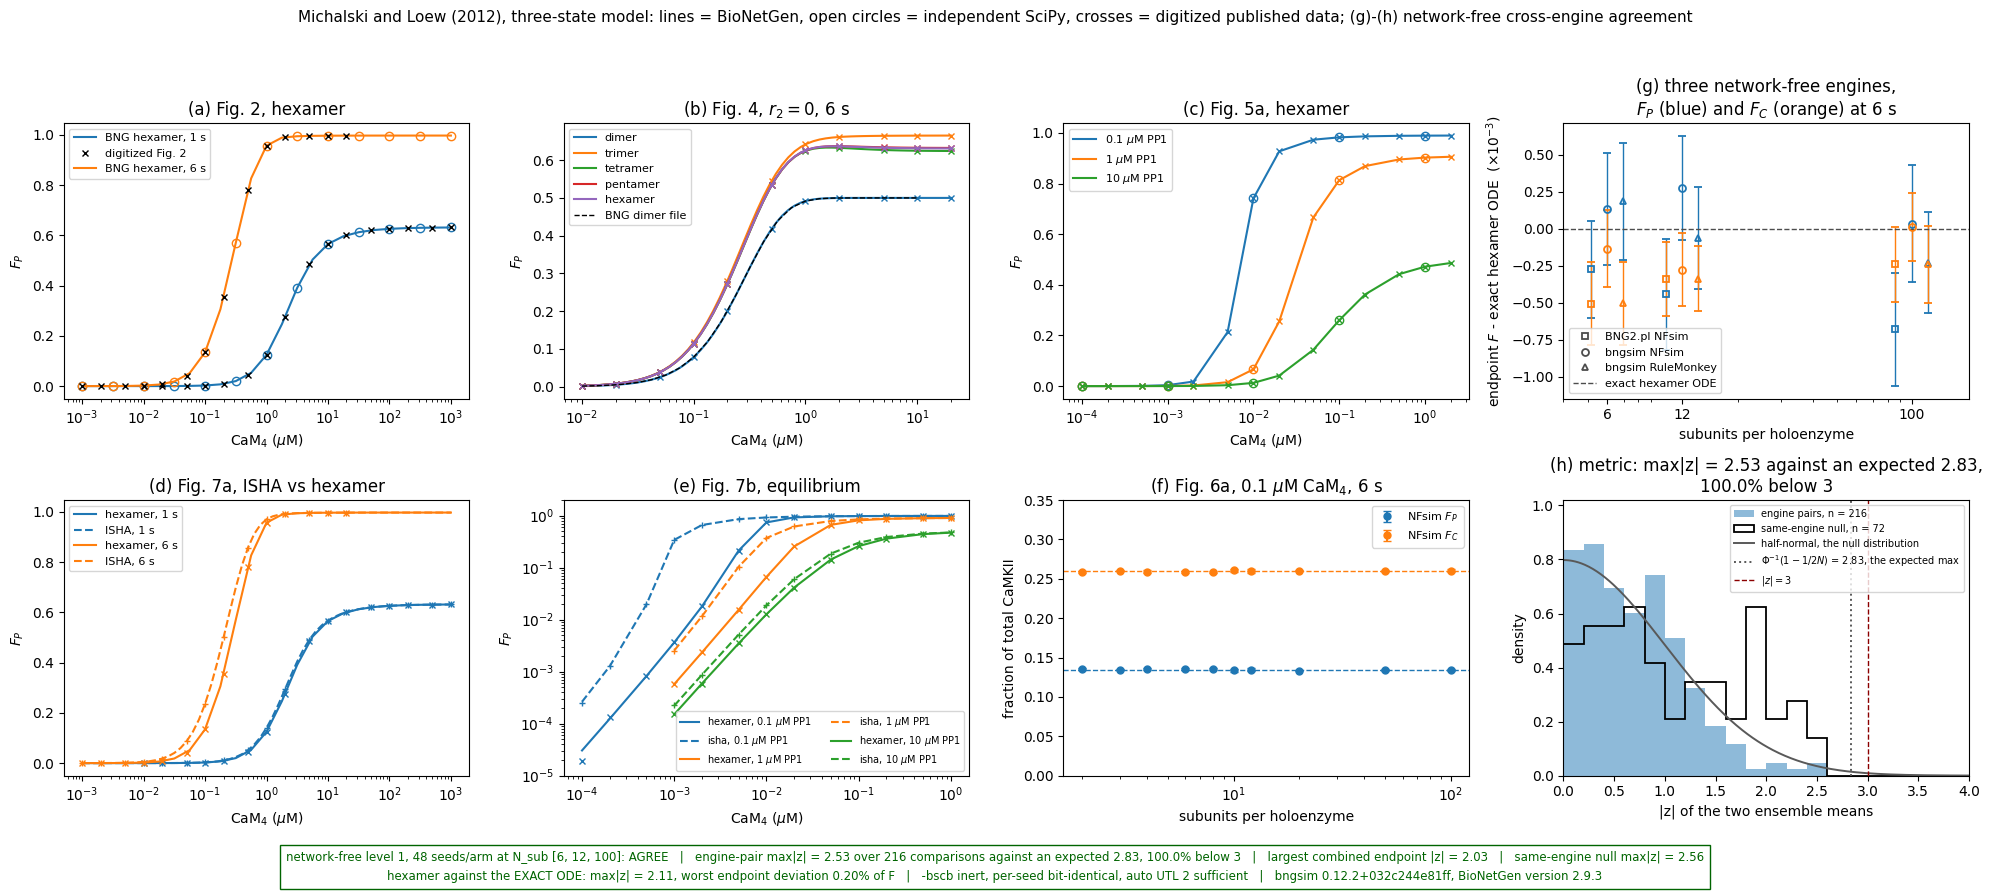

In [15]:
fig, ax = plt.subplots(2, 4, figsize=(20, 9))
COL = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# (a) Fig. 2
a = ax[0, 0]
d = RUNS[f"{STEM}.bngl"]
for k, (tag, tstep) in enumerate((("1s", 1.0), ("6s", 6.0))):
    cam, fp = scan_series(d, STEM, "scan", "FP", step=tstep)
    a.semilogx(cam, fp, "-", lw=1.5, color=COL[k], label=f"BNG hexamer, {tstep:.0f} s")
    ind = np.array([ring_solve(6, {**BASE, "CaM4": c}, np.array([0.0, tstep]))[0][-1] for c in cam])
    a.semilogx(cam[::2], ind[::2], "o", mfc="none", mec=COL[k], ms=6)
    cr, fr = digitized(f"fig2_{tag}_hexamer")
    a.semilogx(cr, fr, "x", color="k", ms=5, mew=1.0,
               label="digitized Fig. 2" if k == 0 else None)
a.set(xlabel=r"CaM$_4$ ($\mu$M)", ylabel=r"$F_P$", title="(a) Fig. 2, hexamer")
a.legend(fontsize=8)

# (b) Fig. 4
a = ax[0, 1]
for k, (name, N) in enumerate(SIZES.items()):
    cr, fr = digitized(f"fig4_{name}")
    grid = np.logspace(-2, np.log10(20), 60)
    mod = np.array([ring_solve(N, {**BASE, "r2": 0.0, "CaM4": c}, np.array([0.0, 6.0]))[0][-1]
                    for c in grid])
    a.semilogx(grid, mod, "-", lw=1.5, color=COL[k], label=name)
    a.semilogx(cr, fr, "x", color=COL[k], ms=5, mew=1.0)
a.semilogx(cam0, fp0, "--", lw=1.0, color="k", label="BNG dimer file")
a.set(xlabel=r"CaM$_4$ ($\mu$M)", ylabel=r"$F_P$", title=r"(b) Fig. 4, $r_2=0$, 6 s")
a.legend(fontsize=8)

# (c) Fig. 5a
a = ax[0, 2]
for k, (tag, pp1) in enumerate(PP1_LEVELS.items()):
    cam, tabs = PP1_RUNS[tag]
    a.semilogx(cam, at_time(tabs, 50000.0), "-", lw=1.5, color=COL[k],
               label=f"{pp1:g} " + r"$\mu$M PP1")
    ind = np.array([ring_solve(6, {**BASE, "CaM4": c, "PP1": pp1}, np.array([0.0, 50000.0]),
                               with_pp1=True)[0][-1] for c in cam[::3]])
    a.semilogx(cam[::3], ind, "o", mfc="none", mec=COL[k], ms=6)
    cr, fr = digitized(f"fig5a_pp1_{tag}uM_hexamer")
    a.semilogx(cr, fr, "x", color=COL[k], ms=5, mew=1.0)
a.set(xlabel=r"CaM$_4$ ($\mu$M)", ylabel=r"$F_P$", title="(c) Fig. 5a, hexamer")
a.legend(fontsize=8)

# (d) Fig. 7a
a = ax[1, 0]
for k, (tag, tstep) in enumerate((("1s", 1.0), ("6s", 6.0))):
    cam, fp = scan_series(RUNS[f"{STEM}.bngl"], STEM, "scan", "FP", step=tstep)
    a.semilogx(cam, fp, "-", lw=1.5, color=COL[k], label=f"hexamer, {tstep:.0f} s")
    cam, fp = scan_series(RUNS[f"{STEM}_isha.bngl"], f"{STEM}_isha", "scan", "FP", step=tstep)
    a.semilogx(cam, fp, "--", lw=1.5, color=COL[k], label=f"ISHA, {tstep:.0f} s")
    for who, mark in (("hexamer", "x"), ("isha", "+")):
        cr, fr = digitized(f"fig7a_{who}_{tag}")
        a.semilogx(cr, fr, mark, color=COL[k], ms=5, mew=1.0)
a.set(xlabel=r"CaM$_4$ ($\mu$M)", ylabel=r"$F_P$", title="(d) Fig. 7a, ISHA vs hexamer")
a.legend(fontsize=8)

# (e) Fig. 7b
a = ax[1, 1]
for k, (tag, pp1) in enumerate(PP1_LEVELS.items()):
    for who, style, mark in (("hexamer", "-", "x"), ("isha", "--", "+")):
        cam, tabs = FIG7B_RUNS[(tag, who)]
        a.loglog(cam, at_time(tabs, 50000.0), style, lw=1.5, color=COL[k],
                 label=f"{who}, {pp1:g} " + r"$\mu$M PP1")
        cr, fr = digitized(f"fig7b_pp1_{tag}uM_{who}")
        a.loglog(cr, fr, mark, color=COL[k], ms=5, mew=1.0)
a.set(xlabel=r"CaM$_4$ ($\mu$M)", ylabel=r"$F_P$", ylim=(1e-5, 2),
      title="(e) Fig. 7b, equilibrium")
a.legend(fontsize=7, ncol=2)

# (f) Fig. 6a
a = ax[1, 2]
for j, (lab, col) in enumerate((("$F_P$", COL[0]), ("$F_C$", COL[1]))):
    m = np.array([nf[N][:, j].mean() for N in NS])
    s = np.array([nf[N][:, j].std(ddof=1) for N in NS])
    a.errorbar(NS, m, yerr=s, fmt="o", color=col, ms=5, capsize=3, label=f"NFsim {lab}")
a.axhline(fp_ode, ls="--", lw=1.0, color=COL[0])
a.axhline(fc_ode, ls="--", lw=1.0, color=COL[1])
a.set_xscale("log")
a.set(xlabel="subunits per holoenzyme", ylabel="fraction of total CaMKII",
      ylim=(0, 0.35), title=r"(f) Fig. 6a, 0.1 $\mu$M CaM$_4$, 6 s")
a.legend(fontsize=8)

# (g) the three network-free engines at the three holoenzyme sizes, as a deviation from the
# exact hexamer ODE. At N_sub = 6 the zero line is the exact answer; at 12 and 100 the offset
# from it is the size independence Fig. 6a claims, resolved here to about 1e-4 in F.
a = ax[0, 3]
JITTER = {"bng_nf": 0.86, "bngsim_nf": 1.0, "bngsim_rm": 1.16}
MARK = {"bng_nf": "s", "bngsim_nf": "o", "bngsim_rm": "^"}
for j, o in enumerate(OBS):
    for arm in ENGINES:
        m, s = (np.array([mean_se(ENS[(arm, N)][o])[k][-1] for N in AGREE_SIZES])
                for k in (0, 1))
        a.errorbar(np.array(AGREE_SIZES, float) * JITTER[arm], (m - EXACT[o][-1]) * 1e3,
                   yerr=s * 1e3, fmt=MARK[arm], color=COL[j], ms=5, mfc="none", mew=1.3,
                   capsize=3, lw=1.0)
a.axhline(0.0, ls="--", lw=1.0, color="0.3")
for arm in ENGINES:
    a.plot([], [], MARK[arm], color="0.3", mfc="none", mew=1.3, ms=5, label=ENG_LABEL[arm])
a.plot([], [], "--", color="0.3", lw=1.0, label="exact hexamer ODE")
a.set_xscale("log")
a.set_xticks(AGREE_SIZES, [str(N) for N in AGREE_SIZES])
a.set(xlabel="subunits per holoenzyme", xlim=(4, 170),
      ylabel=r"endpoint $F$ - exact hexamer ODE  ($\times 10^{-3}$)",
      title="(g) three network-free engines,\n"
            + r"$F_P$ (blue) and $F_C$ (orange) at 6 s")
a.legend(fontsize=8, loc="lower left")

# (h) the metric itself: |z| of the two ensemble means against the half-normal it should
# follow, with the expected maximum of that many draws drawn where a reader can see it.
a = ax[1, 3]
Z_CROSS = np.abs(np.concatenate([pair_z(ENS[(p, N)][o], ENS[(q, N)][o])
                                 for N in AGREE_SIZES for p, q in PAIRS for o in OBS]))
Z_NULL = np.abs(np.concatenate([pair_z(ENS[("bngsim_rm", N)][o], ENS[("null_rm", N)][o])
                                for N in AGREE_SIZES for o in OBS]))
bins = np.linspace(0, 4, 21)
a.hist(Z_CROSS, bins=bins, density=True, color=COL[0], alpha=0.5,
       label=f"engine pairs, n = {Z_CROSS.size}")
a.hist(Z_NULL, bins=bins, density=True, histtype="step", color="k", lw=1.3,
       label=f"same-engine null, n = {Z_NULL.size}")
gg = np.linspace(0, 4, 400)
a.plot(gg, 2 * np.exp(-gg ** 2 / 2) / np.sqrt(2 * np.pi), "-", color="0.35", lw=1.4,
       label="half-normal, the null distribution")
a.axvline(TRAJ["exp_max"], ls=":", color="0.35", lw=1.4)
a.axvline(3.0, ls="--", color="darkred", lw=1.0)
a.plot([], [], ":", color="0.35", lw=1.4,
       label=r"$\Phi^{-1}(1-1/2N)$ = " + f"{TRAJ['exp_max']:.2f}, the expected max")
a.plot([], [], "--", color="darkred", lw=1.0, label=r"$|z| = 3$")
a.set(xlabel="|z| of the two ensemble means", ylabel="density", xlim=(0, 4), ylim=(0, 1.02),
      title=f"(h) metric: max|z| = {TRAJ['zmax']:.2f} against an expected "
            f"{TRAJ['exp_max']:.2f},\n{TRAJ['frac3']:.1%} below 3")
a.legend(fontsize=7, loc="upper right")

fig.suptitle("Michalski and Loew (2012), three-state model: lines = BioNetGen, "
             "open circles = independent SciPy, crosses = digitized published data; "
             "(g)-(h) network-free cross-engine agreement",
             fontsize=11)
fig.tight_layout(rect=(0, 0.055, 1, 0.955))

# The verdict belongs on the figure: a reader should not have to open the notebook to
# learn how well the engines agreed (curate-model, "Verification Artifact Shape").
fig.text(0.5, 0.010,
         f"network-free level 1, {AGREE_SEEDS} seeds/arm at N_sub "
         f"{list(AGREE_SIZES)}: {AGREE_VERDICT}   |   engine-pair max|z| = "
         f"{TRAJ['zmax']:.2f} over {TRAJ['n']} comparisons against an expected "
         f"{TRAJ['exp_max']:.2f}, {TRAJ['frac3']:.1%} below 3   |   largest combined "
         f"endpoint |z| = {END_ZMAX:.2f}   |   same-engine null max|z| = "
         f"{NULL['zmax']:.2f}\n"
         f"hexamer against the EXACT ODE: max|z| = {ODE['zmax']:.2f}, worst endpoint "
         f"deviation {ODE_REL:.2%} of F   |   -bscb inert, per-seed bit-identical, auto "
         f"UTL {AUTO_UTL} sufficient   |   bngsim {BNGSIM_BUILD}, {BNG_VERSION}",
         ha="center", va="bottom", fontsize=8.5, linespacing=1.6, color="darkgreen",
         bbox={"fc": "white", "ec": "darkgreen", "pad": 4})
fig.savefig(HERE / "verify_michalski2012.png", dpi=150)
plt.show()

## 8. Summary

In [16]:
print("Model-specification verification (BioNetGen vs independent SciPy)")
for label, err in SUMMARY:
    print(f"  {label:60s} {err:.3e}")
worst = max(e for _, e in SUMMARY)
print(f"  worst case: {worst:.3e}")
assert worst < 1e-5

print("\nReported-data verification (BioNetGen vs digitized published curves)")
for label, dev, tol in FIGERR:
    flag = "OK" if dev <= tol else "OVER TOLERANCE"
    print(f"  {label:44s} max |dFP| = {dev:.4f}  tol {tol:.3f}  {flag}")
print("\nFig. 7b, judged as a displacement along its logarithmic ordinate")
for label, dev, tol in FIGERR_LOG:
    flag = "OK" if dev <= tol else "OVER TOLERANCE"
    print(f"  {label:44s} max |dlog10 FP| = {dev:.3f} decades  "
          f"tol {tol:.2f} (one marker)  {flag}")
assert all(dev <= tol for _, dev, tol in FIGERR)
assert all(dev <= tol for _, dev, tol in FIGERR_LOG)

print("\nNetwork-free verification of _nfsim.bngl above the hexamer, where no network "
      "can be generated")
print(f"  three engines, {AGREE_SEEDS} seeds/arm, N_sub {list(AGREE_SIZES)}: "
      f"{AGREE_VERDICT}")
print(f"  {'engine-pair max|z|':44s} {TRAJ['zmax']:.2f}  "
      f"expected max of {TRAJ['n']} normals {TRAJ['exp_max']:.2f}, "
      f"{TRAJ['frac3']:.1%} below 3")
print(f"  {'same-engine null max|z|':44s} {NULL['zmax']:.2f}  "
      f"expected {NULL['exp_max']:.2f} over {NULL['n']}")
print(f"  {'largest combined endpoint |z|':44s} {END_ZMAX:.2f}")
print(f"  {'hexamer vs the exact ODE, max|z|':44s} {ODE['zmax']:.2f}  "
      f"worst endpoint deviation {ODE_REL:.2%} of F")
print(f"  {'-bscb / -utl determination':44s} inert; auto UTL {AUTO_UTL} sufficient, "
      f"per-seed bit-identical")
assert AGREE_OK and FLAGS_INERT

print("\nAll checks passed.")

Model-specification verification (BioNetGen vs independent SciPy)
  hexamer 1 s: BNG vs independent enumeration                  5.522e-07
  hexamer 6 s: BNG vs independent enumeration                  3.514e-07
  dimer 6 s: BNG vs Eq. 6                                      3.706e-08
  dimer 6 s, r2 = 0: BNG vs Eq. 6                              3.403e-09
  hexamer + 1 uM PP1: BNG vs independent enumeration           5.412e-09
  ISHA 6 s: BNG vs Eq. 7                                       2.185e-07
  ISHA + 1 uM PP1: BNG vs Eq. 7                                5.479e-09
  worst case: 5.522e-07

Reported-data verification (BioNetGen vs digitized published curves)
  Fig. 2 hexamer 1s                            max |dFP| = 0.0000  tol 0.004  OK
  Fig. 2 hexamer 6s                            max |dFP| = 0.0000  tol 0.004  OK
  Fig. 2 dimer 1s                              max |dFP| = 0.0000  tol 0.004  OK
  Fig. 2 dimer 6s                              max |dFP| = 0.0000  tol 0.004  OK
  Fig